# 1. Environment Setup

In [1]:
import sys 
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'datasets': 'datasets',
    'pyarrow': 'pyarrow',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
}

print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

All dependencies already installed.



In [2]:
# Import Core Libraries
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset
import os
import matplotlib.pyplot as plt
import seaborn as sns


# Disable HuggingFace Hub symlinks warning on Windows
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [3]:
DIR = "../data/sourced/"
CLEANED_PARQUET = os.path.join(DIR, "clean_reviews.parquet")

# RANDOM_STATE = 42
# SAMPLE_SIZE = 15_000_000 # Was not used due to network issues in streaming

PRODUCT_SIZE = 5 # Minimum number of reviews per product (parent level)

# 2. Load the Dataset

In [4]:
# CONFIGURATION
REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

print(f"Configuration:")
# print(f"  Sample Size: {SAMPLE_SIZE:,}")
# print(f"  Random State: {RANDOM_STATE}")
print(f"  Source: Amazon Electronics Reviews (Hugging Face)\n")

Configuration:
  Source: Amazon Electronics Reviews (Hugging Face)



In [5]:
# # Load Dataset (Streaming)
# import itertools

# print(f"Loading {SAMPLE_SIZE:,} reviews from Amazon Electronics dataset...\n")

# ds_iter = load_dataset("json", data_files=REVIEWS_URL, split="train", streaming=True)
# sample = list(tqdm(itertools.islice(ds_iter, SAMPLE_SIZE), total=SAMPLE_SIZE, desc="Streaming"))

# df = Dataset.from_list(sample).to_pandas()

# print(f"\nDataset loaded: {len(df):,} reviews.")
# print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

In [6]:
# Load Dataset — skip the full 43M-row non-streaming load if the final pipeline
# output already exists; load a small streamed sample instead so this notebook
# still runs end-to-end for verification without hours of re-download/reprocessing.
FINAL_OUTPUT = "../data/processed/amazon_reviews_s30.parquet"
if os.path.exists(FINAL_OUTPUT):
    print(f"{FINAL_OUTPUT} already exists — loading a 50k-row streamed sample instead of the full 43M-row dataset.")
    ds_stream = load_dataset("json", data_files=REVIEWS_URL, split="train", streaming=True)
    df = pd.DataFrame(list(ds_stream.take(50_000)))
else:
    ds = load_dataset("json", data_files=REVIEWS_URL, split="train")
    df = pd.DataFrame(ds)

print(f"\nDataset loaded: {len(df):,} reviews.")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

../data/processed/amazon_reviews_s30.parquet already exists — loading a 50k-row streamed sample instead of the full 43M-row dataset.



Dataset loaded: 50,000 reviews.
Memory Usage: 27.44 MB



# 3. Quick Overview

In [7]:
print("Shape of DataFrame:", df.shape)

Shape of DataFrame: (50000, 10)


In [8]:
print(f"Column Data Types:\n{df.dtypes}")

Column Data Types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


In [9]:
missing = df.isnull().sum()

if missing.sum() == 0:
    print(" No missing detected!")
else:
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count:,} missing values. ({count/len(df)*100:.1f}%)")

 No missing detected!


In [10]:
print("Dataset preview:")
df.head()

Dataset preview:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


# 4. Visualization (Before Fundamental Cleaning)

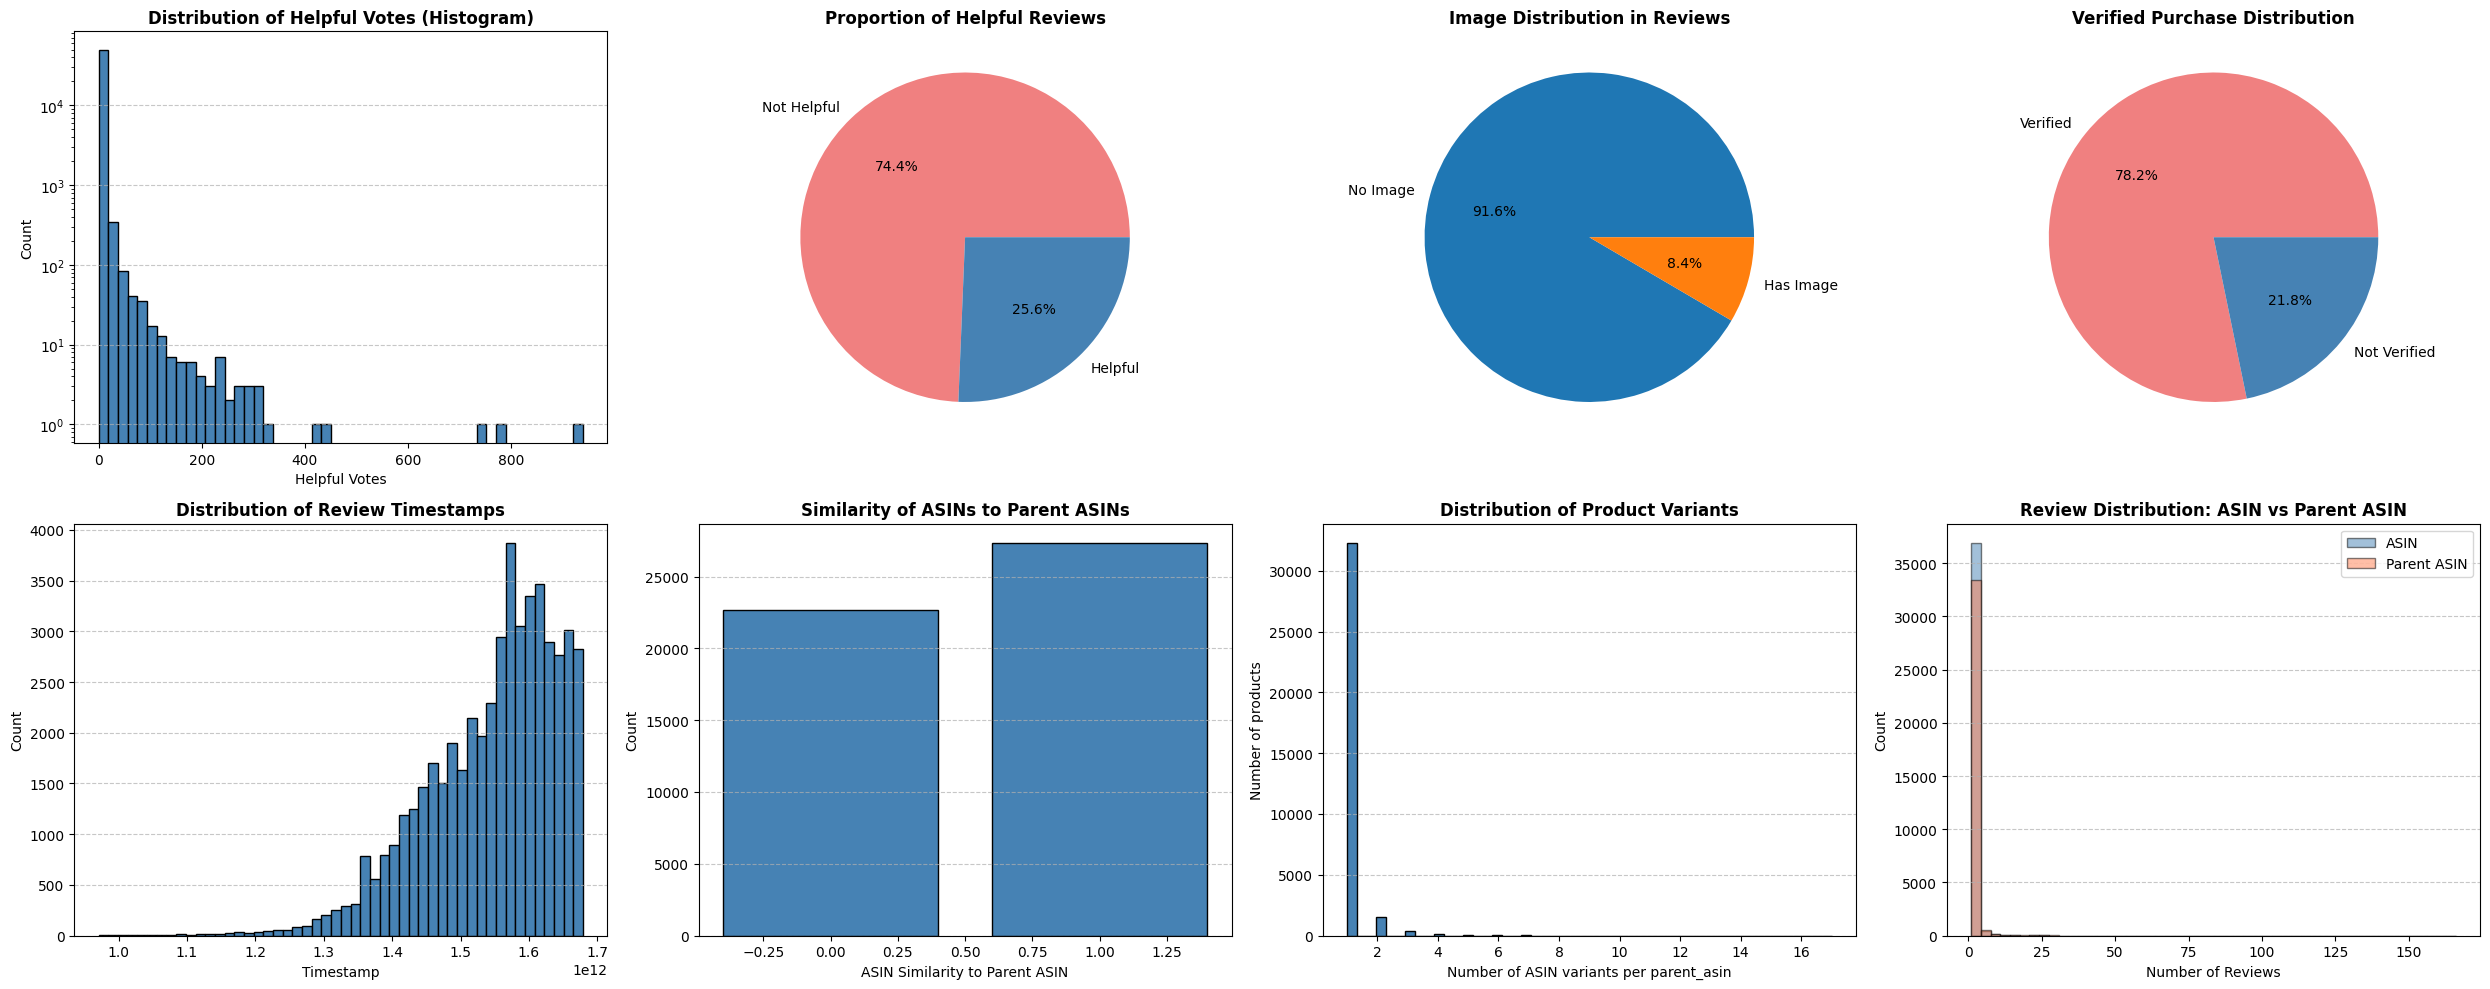

In [11]:
# Section 4: All Visualizations Combined into Subplots
fig, axes = plt.subplots(2, 4, figsize=(25, 10))
axes = axes.flatten()


# 1. Helpful Votes Histogram
axes[0].hist(df['helpful_vote'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Helpful Votes (Histogram)', fontweight='bold')
axes[0].set_xlabel('Helpful Votes')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Helpful Votes Pie Chart
is_helpful_review = df['helpful_vote'] > 0
counts = is_helpful_review.value_counts(sort=False).sort_index()
axes[1].pie(counts, labels=['Not Helpful', 'Helpful'], autopct='%1.1f%%', 
            colors=['lightcoral', 'steelblue'])
axes[1].set_title('Proportion of Helpful Reviews', fontweight='bold')

# 3. Image Distribution
has_image = df['images'].map(len).gt(0).value_counts()
axes[2].pie(has_image.values, 
            labels=['Has Image' if i else 'No Image' for i in has_image.index],
            autopct='%1.1f%%')
axes[2].set_title('Image Distribution in Reviews', fontweight='bold')

# 4. Verified Purchase Distribution
verified = df['verified_purchase'].value_counts()
axes[3].pie(verified.values, 
            labels=['Verified' if v else 'Not Verified' for v in verified.index],
            autopct='%1.1f%%', colors=['lightcoral', 'steelblue'])
axes[3].set_title('Verified Purchase Distribution', fontweight='bold')

# 5. Timestamp Distribution
axes[4].hist(df['timestamp'], bins=50, color='steelblue', edgecolor='black')
axes[4].set_title('Distribution of Review Timestamps', fontweight='bold')
axes[4].set_xlabel('Timestamp')
axes[4].set_ylabel('Count')
axes[4].grid(axis='y', linestyle='--', alpha=0.7)

# 6. ASIN Similarity
same_id = (df['asin'] == df['parent_asin']).value_counts().sort_index()
axes[5].bar(same_id.index, same_id.values, color='steelblue', edgecolor='black')
axes[5].set_xlabel('ASIN Similarity to Parent ASIN')
axes[5].set_ylabel('Count')
axes[5].set_title('Similarity of ASINs to Parent ASINs', fontweight='bold')
axes[5].grid(axis='y', linestyle='--', alpha=0.7)

# 7. Distribution of Product Variants
variant_counts = df.groupby("parent_asin")["asin"].nunique()
axes[6].hist(variant_counts, bins=50, color='steelblue', edgecolor='black')
axes[6].set_xlabel('Number of ASIN variants per parent_asin')
axes[6].set_ylabel('Number of products')
axes[6].set_title('Distribution of Product Variants', fontweight='bold')
axes[6].grid(axis='y', linestyle='--', alpha=0.7)

# 8. Review Distribution: ASIN vs Parent ASIN
reviews_per_asin = df.groupby("asin").size()
reviews_per_parent = df.groupby("parent_asin").size()
axes[7].hist(reviews_per_asin, bins=50, alpha=0.5, label="ASIN", color='steelblue', edgecolor='black')
axes[7].hist(reviews_per_parent, bins=50, alpha=0.5, label="Parent ASIN", color='coral', edgecolor='black')
axes[7].legend()
axes[7].set_xlabel('Number of Reviews')
axes[7].set_ylabel('Count')
axes[7].set_title('Review Distribution: ASIN vs Parent ASIN', fontweight='bold')
axes[7].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 4.1 Initial Rating Distribution Insights

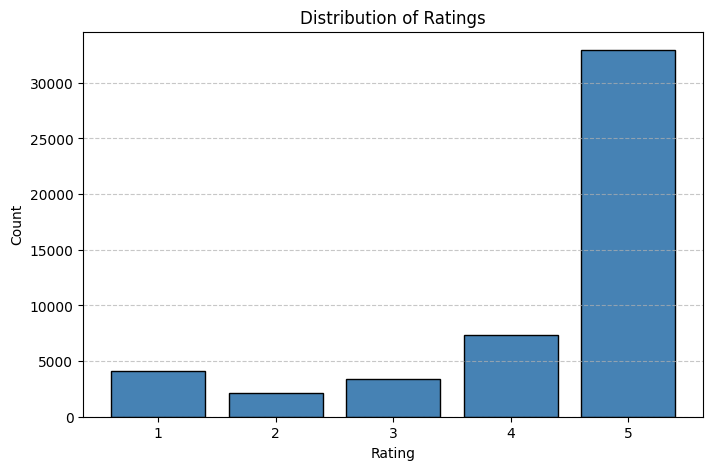


⭐ Rating Distribution:
  1.0:   8.3% ██
  2.0:   4.2% █
  3.0:   6.8% ██
  4.0:  14.8% ████
  5.0:  65.9% █████████████████████


In [12]:
# Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rating_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\n⭐ Rating Distribution:")
for rating in sorted(df['rating'].unique()):
    count = (df['rating'] == rating).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f"  {rating}: {pct:5.1f}% {bar}")

## 4.2 ASIN vs Parent ASIN Structure

Each `parent_asin` represents a product family, while individual `asin` values correspond to specific product variants (e.g., colour or size).

The following visualization shows how many ASIN variants belong to each parent product, illustrating why analysis should be performed at the parent product level rather than the variant level.

                parent_asin (Product)
                      │
        ┌─────────────┼─────────────┐
        │             │             │
      asin          asin          asin
   (variant)     (variant)     (variant)

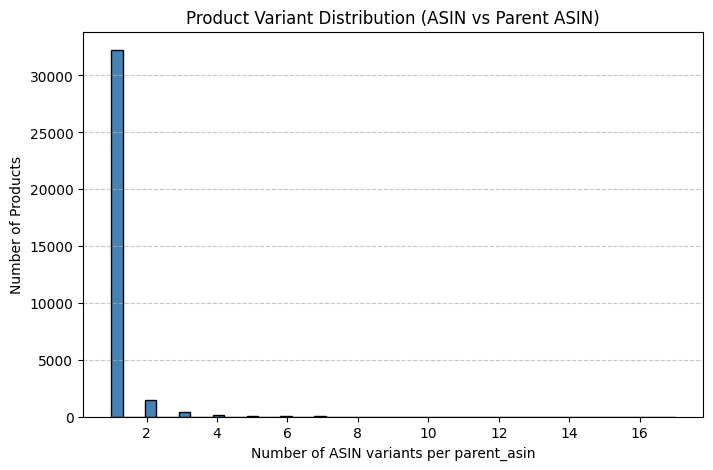

In [13]:
# Number of ASIN variants per parent product
variants_per_product = (
    df.groupby("parent_asin")["asin"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.hist(variants_per_product, bins=50, color='steelblue', edgecolor='black')

plt.xlabel("Number of ASIN variants per parent_asin")
plt.ylabel("Number of Products")
plt.title("Product Variant Distribution (ASIN vs Parent ASIN)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 5. Basic Data Quality and Content Filtering

In [14]:
print("Filtering for rows with valid content and required fields...")
rows_before = len(df)

# Remove rows where all elements are missing
df = df.dropna(how='all')
print(f"  After dropping completely empty rows: {df.shape[0]:,} rows")

# Keep rows with non-empty text OR title
df = df[(df['text'].fillna('').str.strip().str.len() > 0) | 
        (df['title'].fillna('').str.strip().str.len() > 0)]
print(f"  After filtering for content (text or title): {df.shape[0]:,} rows")

# Drop rows missing critical columns
df = df.dropna(subset=["text", "helpful_vote", "rating"])
print(f"  After dropping rows with missing critical fields: {df.shape[0]:,} rows")

# Summary
rows_dropped = rows_before - df.shape[0]
rows_pct = (rows_dropped / rows_before * 100) if rows_before > 0 else 0
print(f"\nTotal rows removed: {rows_dropped:,} ({rows_pct:.1f}%)\n")

Filtering for rows with valid content and required fields...
  After dropping completely empty rows: 50,000 rows
  After filtering for content (text or title): 50,000 rows
  After dropping rows with missing critical fields: 50,000 rows

Total rows removed: 0 (0.0%)



Save Raw Dataset --> To keep the raw data, if required later on

In [15]:
df_save = df.copy()

In [16]:
df = df_save.copy()

# 6. Cleaning --> According to the problem statement

## 6.1 Filter Reviews with helpful votes

Filtering to helpful_votes > 0 restricts the dataset to reviews that received actual community engagement, meaning at least one user interacted with the review and evaluated its usefulness.
This removes reviews that were never seen or evaluated by users, ensuring the model learns from socially validated feedback signals rather than treating unobserved reviews as implicitly “not helpful.”

In [17]:
df = df[df['helpful_vote'] > 0].copy()

print(f"  After filtering for helpful reviews, dataset shape: {df.shape[0]:,} rows.")

  After filtering for helpful reviews, dataset shape: 12,824 rows.


## 6.2 Product Level Filtering

Considering the reviews only when a product has at least 5 reviews that have helpful_votes>0. 

In [18]:
# Count qualifying reviews per product (parent level)
product_counts = df.groupby("parent_asin").size()

# Identify products with at least 5 qualifying reviews
valid_products = product_counts[product_counts >= PRODUCT_SIZE].index

# Filter original dataframe
df = df[df["parent_asin"].isin(valid_products)]

print(f"  After filtering for products with >= {PRODUCT_SIZE} helpful reviews, dataset shape: {df.shape[0]:,} rows.\n")

  After filtering for products with >= 5 helpful reviews, dataset shape: 272 rows.



## 6.3 Dropping unncessary columns

**user_id**: Drop user_id because reviewer identity does not generalise to unseen users, risks data leakage and bias, and adds privacy-sensitive information with no predictive value for review helpfulness.

In [19]:
df.drop(columns=['user_id'], inplace=True)

print(f"  After dropping 'user_id' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'user_id' column, dataset shape: 272 x 9.


**asin**: Drop asin because it represents individual product variants (colour/size versions), which fragments the data and introduces artificial duplication, whereas parent_asin already groups all variants under the true product.

**parent_asin**: Keep parent_asin because it preserves product-level context needed for business insights, clustering, and later merchant recommendations.

In [20]:
df.drop(columns=['asin'], inplace=True)

print(f"  After dropping 'asin' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'asin' column, dataset shape: 272 x 8.


# 7. Reduce Memory Usage

In [21]:
print(f"Before dtype conversion\n{df.dtypes}")

Before dtype conversion
rating               float64
title                    str
text                     str
images                object
parent_asin              str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


In [22]:
# Conversion of data types to optimize memory usage
dtype_mapping = {
    'rating': 'int8',
    'parent_asin': 'category',
    'helpful_vote': 'int32',
}

before_mem = df.memory_usage(deep=True).sum() / 1024**2
df = df.astype(dtype_mapping)
after_mem = df.memory_usage(deep=True).sum() / 1024**2

print(f"\nMemory Usage Optimization:")
print(f"  Before optimization, memory usage: {before_mem:.2f} MB")
print(f"  After optimization, memory usage: {after_mem:.2f} MB")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
print(f"  After converting 'timestamp' to datetime, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")


Memory Usage Optimization:
  Before optimization, memory usage: 0.20 MB
  After optimization, memory usage: 0.19 MB
  After converting 'timestamp' to datetime, dataset shape: 272 x 8.


In [23]:
print(f"After dtype conversion\n{df.dtypes}")

After dtype conversion
rating                         int8
title                           str
text                            str
images                       object
parent_asin                category
timestamp            datetime64[ms]
helpful_vote                  int32
verified_purchase              bool
dtype: object


# 8 Save Clean and Filtered File

In [24]:
df.head(2)

,rating,title,text,images,parent_asin,timestamp,helpful_vote,verified_purchase
226,1,NO GOOD! DONT WASTE YOUR MONEY!,Not good! Sound quality is awful! Dont buy!,[],B09Q5BNT76,2021-06-24 14:54:39.507,1,True
360,5,MY KINDLE FIRE,Love it; Love it; Love it! I got the Kindle F...,[],B0051VVOB2,2012-01-22 20:16:28.000,1,True


In [25]:
# Create directory if it doesn't exist
os.makedirs(DIR, exist_ok=True)

# Export the dataset
df.to_parquet(CLEANED_PARQUET, index=False, engine="pyarrow")
print(f"Cleaned dataset exported to '{CLEANED_PARQUET}'")

Cleaned dataset exported to '../data/sourced/clean_reviews.parquet'
